In [ ]:
import numpy as np
# === Chon text ===
cau = ["My name is Thinh", "I am a fresher", "I study at HCMUT", "My major is Computer Science", "I joined a Machine Learning course",
      "Everyone joined a Machine Learning course", "It is interesting", "I like interesting things"] # >= 8 cau
vocab = sorted ({ w for s in cau for w in s . lower () . split () })
def to_vector ( s ) :
  v = np . zeros (len ( vocab ) )
  for w in s . lower () . split () :
    v [ vocab . index ( w ) ] += 1
  return v
X = np . array ([ to_vector ( s ) for s in cau ]) # ( so_cau , so_tu )
print ( X . shape )

(8, 23)


**Giải thích mỗi hàng/cột đại diện cho gì?**
- Mỗi hàng đại diện cho một câu theo thứ tự trong mảng *cau*.
- Mỗi cột đại diện cho số lần xuất hiện của một từ thuộc BOWs trong từng câu.

In [ ]:
mean = X.mean(axis=0)
center = X - mean
print(X.shape)
print(mean.shape)
print(center.shape)

(8, 23)
(23,)
(8, 23)


**Nhận xét:** ô code này dùng để trừ từng vector trong ma trận *X* cho vector trung bình cột *mean*. Nhưng do kích thước của ma trận *X* và vector trung bình cột *mean* không bằng nhau nên cơ chế broadcasting được numpy sử dụng.

In [ ]:
def cosine_similarity(X, Y=None):
  if Y is None:
    Y = X
  Xn = X/np.linalg.norm(X,axis=1,keepdims=True) #chuan hoa
  Yn = Y/np.linalg.norm(Y,axis=1,keepdims=True)
  return Xn@Yn.T #ma tran tuong dong
np.set_printoptions(linewidth=200)
print(cosine_similarity(X))

[[1.         0.         0.         0.4472136  0.         0.         0.28867513 0.        ]
 [0.         1.         0.25       0.         0.40824829 0.20412415 0.         0.25      ]
 [0.         0.25       1.         0.         0.20412415 0.         0.         0.25      ]
 [0.4472136  0.         0.         1.         0.         0.         0.25819889 0.        ]
 [0.         0.40824829 0.20412415 0.         1.         0.83333333 0.         0.20412415]
 [0.         0.20412415 0.         0.         0.83333333 1.         0.         0.        ]
 [0.28867513 0.         0.         0.25819889 0.         0.         1.         0.28867513]
 [0.         0.25       0.25       0.         0.20412415 0.         0.28867513 1.        ]]


**Nhận xét:**
- Việc tính toán giữa hai batch là hai ma trận chứa các vector hàng nhằm mục đích tận dụng cơ chế tính toán song song trên ma trận của thư viện numpy.
- Việc chuẩn hóa cho từng vector hàng trong ma trận X và Y sẽ rút gọn đi phần mẫu số (tích độ dài của hai vector) trong phép tính consine. Điều này giúp hạn chế mất tài nguyên tính toán khi phải tính các độ dài của các vector lập lại nhiều lần.
- Tham số *keepdims=True* và cơ chế *Broadcasting* giúp phép chia *X/np.linalg.norm(X,axis=1,keepdims=True)* này chạy được.
- Kết quả trả về là một ma trận biểu diễn giá trị cosine similarity giữa các vector, nằm trong khoảng -1 đến 1.


In [ ]:
def semantic_search(query,top_k=3):
  query = to_vector(query)
  # Reshape query to be 2D for consistency with cosine_similarity, even if it's a single vector
  if query.ndim == 1:
    query = query.reshape(1, -1)
  sims = cosine_similarity(X,query).flatten()
  idx = np.argsort(sims)[-top_k:][::-1]
  return [(cau[i], round(float(sims[i]),3)) for i in idx]

Nhận xét: hàm này đơn giản là tìm *k* câu tương đồng nhất trong mảng *câu* với câu *query*, đánh giá sự tương đồng dựa trên giá trị cosine similarity.

**Nhận xét. Cặp nào giống nhau nhất, cặp nào khác biệt nhất? Kết quả có khớp trực giác không?**

Để đưa ra nhận xét hãy xem qua ma trận tương đồng của batch X ở bài 1.3.
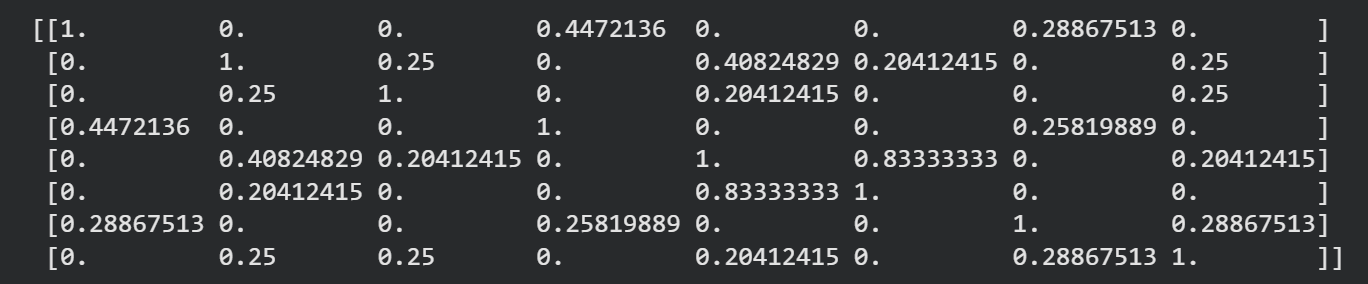
- Cặp giống nhất: Câu 5 (idx=4) (*"I joined a Machine Learning course"*) và Câu 6 (idx=5) (*"Everyone joined a Machine Learning course"*). Điểm cosine cao nhất (0.83). Khớp trực giác vì cả hai gần như giống nhau, chỉ khác mỗi từ *"I"* và từ *"Everyone"*.
- Cặp khác nhất: Có nhiều cặp điểm 0.0 (vd: Câu 1 (idx=0) *"My name is Thinh"* và Câu 2 (idx=1) *"I am a fresher"*). Khớp trực giác với mô hình BoW vì chúng hoàn toàn không có từ vựng nào trùng lặp, dù về mặt ngữ nghĩa có thể liên quan.

In [ ]:
import matplotlib.pyplot as plt
Xc = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
coords = U[:, :2] * S[:2]
plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], color='coral', edgecolors='red', s=100)
for i, txt in enumerate(cau):
    short_label = f"Câu {i+1}: " + " ".join(txt.split()[:3]) + "..."
    plt.annotate(short_label, (coords[i, 0], coords[i, 1]),
                 xytext=(8, 5), textcoords='offset points', fontsize=9)
plt.title("Biểu diễn các câu trên mặt phẳng 2D sau khi giảm chiều bằng SVD")
plt.xlabel("Trục chính 1 (Principal Component 1)")
plt.ylabel("Trục chính 2 (Principal Component 2)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Nhận xét:**
- **Các câu cùng chủ đề có nằm gần nhau không?** Có, các câu có ngữ nghĩa hoặc từ vựng chia sẻ chung sẽ có xu hướng nằm gần nhau và hình thành các cụm (cluster) trong không gian đặc trưng. Ví dụ: Nhóm câu liên quan đến "Machine Learning" (Câu 5, Câu 6) sẽ tụ lại một góc, trong khi các câu mang tính chất giới thiệu bản thân (Câu 1, Câu 2) sẽ nằm xa nhóm kia. Điều này thể hiện rõ việc máy tính có thể phân tách dữ liệu văn bản dựa vào độ tương đồng của vector.
- **Liên hệ với Eigen/PCA và "trục chính của dữ liệu"**:Phương pháp chúng ta vừa làm thực chất là Phân tích thành phần chính (PCA) thông qua phép phân rã SVD. Mục tiêu của việc giảm chiều này là biểu diễn dữ liệu bằng ít chiều hơn (ở đây là 2 chiều) nhưng vẫn giữ lại được phần lớn cấu trúc và thông tin quan trọng nhất của dữ liệu ban đầu (hàng ngàn chiều). Hai trục tọa độ trên đồ thị scatter chính là 2 trục chính của dữ liệu. Chúng tương ứng với các eigenvector có eigenvalue lớn nhất trên ma trận hiệp phương sai, chỉ ra những hướng mà dữ liệu biến thiên (phân tán) mạnh nhất. Nhờ phép chiếu này, ta có thể dễ dàng trực quan hóa các cụm ngữ nghĩa trên mặt phẳng 2D.